In [10]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch,periodogram
from solver import Newmarkpseudo_HSI2, Phi_matrix,accdyn_super
from matrix import bridge
from pseudo_excitation import *

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass = 80    #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


N_bridge = 2




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= pedmass #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])

alpha_COV= np.array([0.17,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV

# Generate a random variable from a normal distribution with considered mean and std_dev from literiture

randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
randomMass = random.gauss(mean_mass, mass_COV*mean_mass)
randomAlpha = [random.gauss(mean_alpha[i], alpha_std[i]) for i in range(len(alpha_COV))]
#randomPhase = [random.uniform(0, 2 * math.pi) for i in range(len(mean_alpha)+1)]
randomVelocity = random.gauss(mean_velocity,std_velocity)
randomPhase = np.zeros(5)


print(randomPace)
print(randomMass)
print(randomAlpha)
print(randomPhase)
print(randomVelocity)

t = np.array(np.arange(0, (length+1) / pedvelocity, hht))   #for the testing length was made 10

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


'''Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = 2 ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

#ped = RandPedestrian(randomMass, randomPace, randomPhase, randomAlpha)
n=1
numped=1
#j=np.size(t)
xr=[0]
#force_at_time_t = np.zeros(np.size(t))

#F=np.zeros((N_bridge,np.size(t)))
#for i in range (np.size(t)):
     
force_at_time_t = calcPedForce(Human,t)

fs=1/hht
frequencies, psd = welch(force_at_time_t, fs=fs,nperseg=1000, nfft=2000 )
frequencies = np.array(frequencies)
psd = np.array(psd)
frequencies=frequencies[frequencies<(4.5)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]


2.1030861878090494
108.78142400415521
[0.5020946790073593, 0.08310906381686317, 0.0424012689103482, 0.01699686814730992]
[0. 0. 0. 0. 0.]
1.2637916449194848


90
90


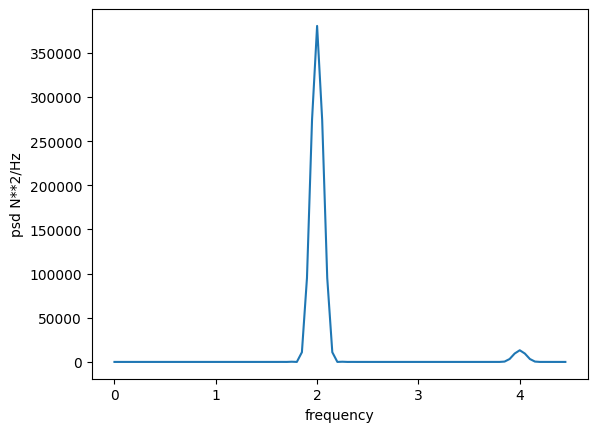

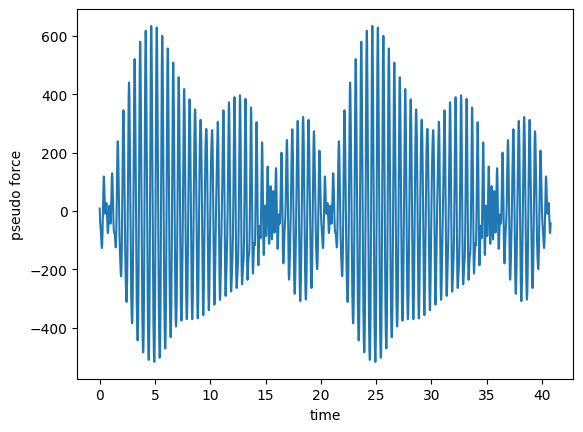

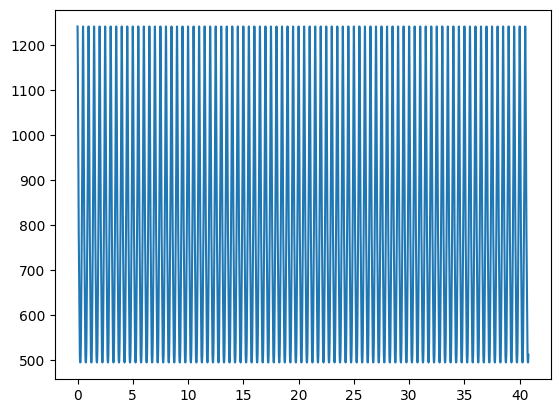

In [11]:
print(np.size(frequencies))
print(np.size(psd))

plt.plot(frequencies,psd)
plt.xlabel("frequency")
plt.ylabel("psd N**2/Hz")
plt.show()

pseudo_force = pseudo_force(psd,frequencies,t)
plt.plot(t,pseudo_force)
plt.xlabel("time")
plt.ylabel("pseudo force")
plt.show()

plt.plot(t,force_at_time_t)
plt.show()

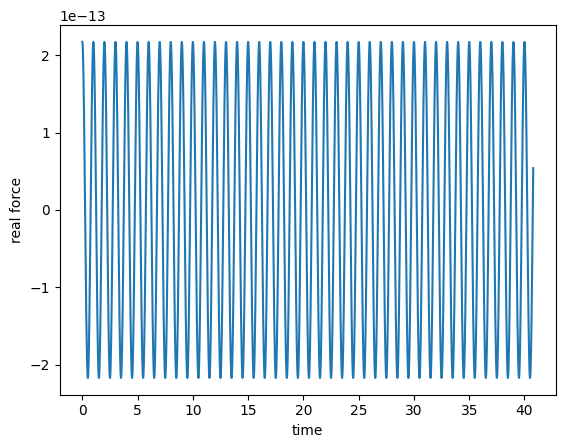

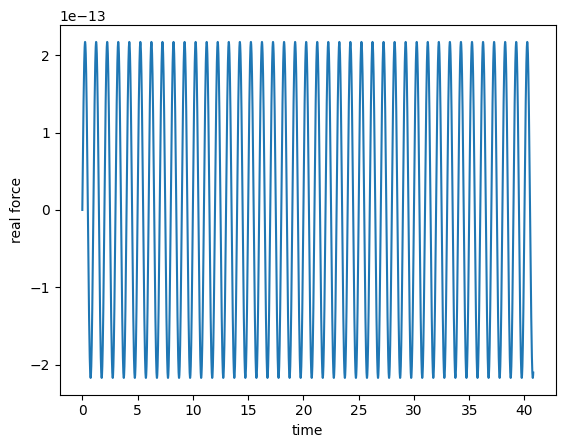

In [3]:
real,imaginary = pseudo_excitation(psd,frequencies,50,1.25,t)
plt.plot(t.flatten(),real[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

[[ 0.00000000e+00  1.64707134e-18  3.26619028e-18 ... -2.71141019e-18
  -4.22339441e-18  0.00000000e+00]
 [ 0.00000000e+00  3.10526621e-18  5.45965008e-18 ... -1.19525543e-18
  -3.57724581e-18  0.00000000e+00]
 [ 0.00000000e+00  2.20692482e-24  1.74396951e-23 ... -9.60074770e-23
  -9.37039437e-23  0.00000000e+00]]
[[ 0.00000000e+00  2.62458934e-08  5.20461095e-08 ... -4.32525404e-08
  -6.73922251e-08  0.00000000e+00]
 [ 0.00000000e+00  4.94820619e-08  8.69984112e-08 ... -1.90449877e-08
  -5.70068597e-08  0.00000000e+00]
 [ 0.00000000e+00  3.51670947e-14  2.77898854e-13 ... -1.53690573e-12
  -1.50042705e-12  0.00000000e+00]]
[[ 0.00000000e+00  2.94905500e-18  5.84794525e-18 ... -4.87570085e-18
  -7.60379988e-18  0.00000000e+00]
 [ 0.00000000e+00  5.55992969e-18  9.77519702e-18 ... -2.13951442e-18
  -6.40673538e-18  0.00000000e+00]
 [ 0.00000000e+00  3.95146375e-24  3.12251844e-23 ... -1.75075064e-22
  -1.71054664e-22  0.00000000e+00]]
[[ 0.00000000e+00  8.00575028e-08  1.58749241e-07 ..

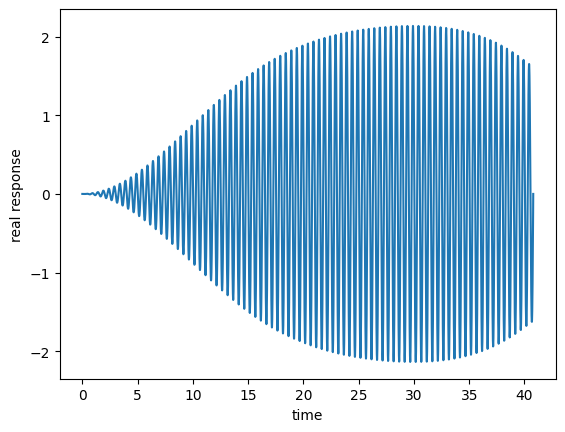

In [4]:
Real_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)


In [5]:
import pickle
with open('Real_responce_with_HSI_.pkl', 'wb') as f:
    pickle.dump(Real_responce, f)

print("Matrix saved to Real_responce_with_HSI_.pkl")

Matrix saved to Real_responce_with_HSI_.pkl


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.00000000e+00 0.00000000e+00 1.64907490e-10 ... 9.93623416e-09
  9.66447361e-09 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.10904068e-10 ... 1.12805165e-09
  1.00837424e-09 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.41921098e-16 ... 5.70485580e-14
  3.80652778e-14 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 3.70586628e-20 ... 2.24138047e-18
  2.18012226e-18 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.98675910e-20 ... 2.53561232e-19
  2.26664185e-19 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 9.93102557e-26 ... 1.30148660e-23
  8.71749062e-24 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 1.50902557e-09 ... 9.18480585e-08
  8.93408459e-08 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.84500231e-09 ... 1.03291339e-08
  9.23370743e-09 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.04390508e-15 ... 5.43395344e-13
  3.66257533e-13 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+0

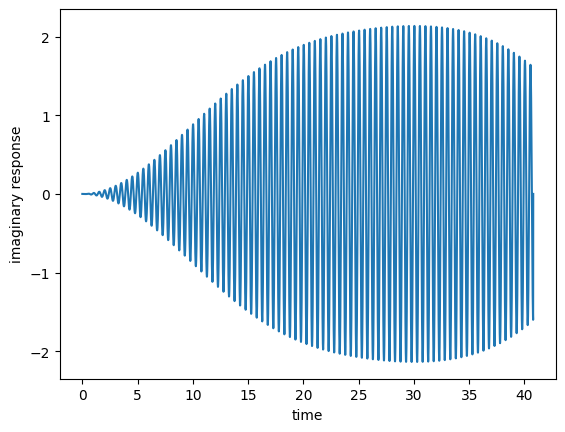

In [6]:
imag_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)



plt.plot(t.flatten(),imag_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)   


In [7]:
import pickle
with open('imag_responce_with_HSI_.pkl', 'wb') as f:
    pickle.dump(imag_responce, f)

print("Matrix saved to imag_responce_with_HSI_.pkl")

Matrix saved to imag_responce_with_HSI_.pkl


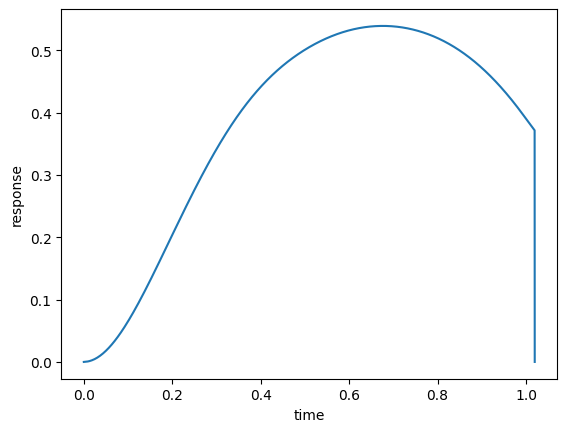

In [8]:
with open('Real_responce_with_HSI_.pkl', 'rb') as f1:
    Real_responce = pickle.load(f1)
with open('imag_responce_with_HSI_.pkl', 'rb') as f2:
    imag_responce = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies)):
        Y[0,[i]] += (Real_responce[[j],[i]]**2 + imag_responce[[j],[i]]**2)*delta_f

deterministic_RMS=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(Xnormal.flatten(),deterministic_RMS.T)
plt.xlabel("time")
plt.ylabel("response")

plt.show()

In [12]:
# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(deterministic_RMS)

# Print the maximum RMS value and its corresponding time
print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")

Maximum 0.5-second RMS value: 0.5389 m/s^2 
